<a href="https://colab.research.google.com/github/JhonHendricksBautista/CPE313_Bautista-Jhon/blob/main/Pytorch_HOA4_1_bautista.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MY MODEL<br>
This model is for classifying fire on the image

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = "/content/drive/MyDrive/datasci3/fire_dataset"

full_dataset = datasets.ImageFolder(
    root=dataset,
    transform=transform
)

print("Classes:", full_dataset.classes)


Classes: ['fire_images', 'non_fire_images']


Data Split

In [3]:
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [7]:
num_epochs = 10
train_acc_list = []
val_acc_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.4f}")

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    print(f"Validation Loss: {val_loss:.4f} "
          f"Validation Accuracy: {val_acc:.4f}")

    train_acc_list.append(epoch_acc)
    val_acc_list.append(val_acc)




Epoch [1/10] Loss: 0.5528 Accuracy: 0.7439
Validation Loss: 0.4138 Validation Accuracy: 0.7833
Epoch [2/10] Loss: 0.3855 Accuracy: 0.7840
Validation Loss: 0.3909 Validation Accuracy: 0.7700
Epoch [3/10] Loss: 0.3036 Accuracy: 0.8813
Validation Loss: 0.2235 Validation Accuracy: 0.9433
Epoch [4/10] Loss: 0.2155 Accuracy: 0.9299
Validation Loss: 0.1791 Validation Accuracy: 0.9233
Epoch [5/10] Loss: 0.1780 Accuracy: 0.9285
Validation Loss: 0.1539 Validation Accuracy: 0.9333
Epoch [6/10] Loss: 0.1640 Accuracy: 0.9571
Validation Loss: 0.1677 Validation Accuracy: 0.9300
Epoch [7/10] Loss: 0.1193 Accuracy: 0.9614
Validation Loss: 0.1094 Validation Accuracy: 0.9500
Epoch [8/10] Loss: 0.1072 Accuracy: 0.9599
Validation Loss: 0.1125 Validation Accuracy: 0.9433
Epoch [9/10] Loss: 0.1477 Accuracy: 0.9485
Validation Loss: 0.2652 Validation Accuracy: 0.8833
Epoch [10/10] Loss: 0.1438 Accuracy: 0.9428
Validation Loss: 0.1006 Validation Accuracy: 0.9500


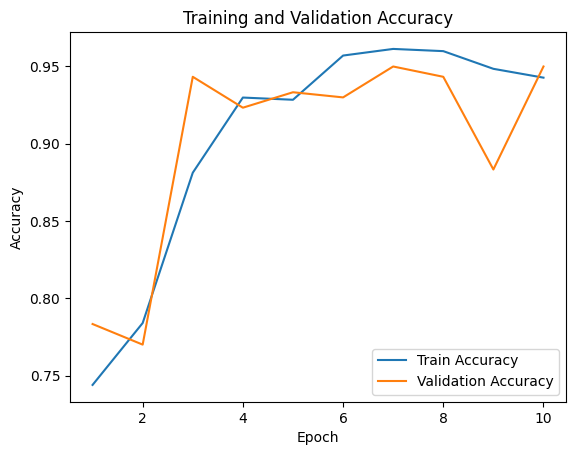

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_list) + 1)

plt.figure()
plt.plot(epochs, train_acc_list, label="Train Accuracy")
plt.plot(epochs, val_acc_list, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()